#### Exercise 8 - Starter - Event Study Time Varying Coefficients 

In Aug 2024, Starbucks announced a CEO change without any other materially confounding information (e.g. it wasn't along an earnings report). Events like these are something companies and investors are regularly interested in quantifying impact -- but naturally don't want to design an experiment randomly giving users bad experiences

Examples of how this might transfer: Suppose there is an outage that affects a certain region or population of users (iOs but not Android, NYC but not San Francisco or LA, purchasers of product X but not Y, etc.). If you have a time series of performance by these groups, you may consider these models to estimate the impact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import statsmodels.formula.api as smf

In [2]:
event_date = '2024-08-13'
prices=pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise7-event-study/data/sbux_ceo_prices.csv')
prices = prices[prices['returns'].isnull()==0].copy()
print(prices['date'].agg(['min','max']))
prices.head()

min    2024-01-03
max    2024-08-30
Name: date, dtype: object


,date,open,high,low,close,adjclose,volume,ticker,returns
1,2024-01-03,93.959999,94.239998,93.059998,93.230003,89.737869,7161700,SBUX,-0.004697
2,2024-01-04,93.099998,94.580002,93.000000,93.550003,90.045891,7118600,SBUX,0.003432
3,2024-01-05,93.330002,93.580002,92.480003,92.989998,89.506851,7189900,SBUX,-0.005986
4,2024-01-08,93.019997,94.570000,92.949997,94.190002,90.661919,7536900,SBUX,0.012905
5,2024-01-09,93.610001,93.730003,92.860001,93.089996,89.603111,6348500,SBUX,-0.011679


### Estimate event study model

In [3]:
np.arange(1,10)# TO-DO: Reshape the data wide so that there is one row per date and a column for each ticker
prices['date']=pd.to_datetime(prices['date'])
event_date=pd.to_datetime(event_date)

df_wide = pd.pivot_table(data=prices, index='date', columns='ticker', values='returns'
                        ).reset_index().sort_values(by='date', ascending=True)

# We do not have one observation per date, so get a trend variable 
# that moves in increments of one for each trading date

# TO-DO: Create a variable df_wide['trend'] that takes on the value of 0 on the event date. 
# It then decreases by 1 for each prior *trading day* and increases by 1 for each successive *trading day*
# Specifically, with no trading on weekends, if trend = 1 on a Friday, it should equal 2 on the next monday
df_wide['t']=np.arange(1, len(df_wide)+1)
event_t = df_wide[df_wide['date']==event_date]['t'].values[0]
df_wide['trend']=df_wide['t']-event_t
df_wide.head()

ticker,date,MCD,SBUX,VOO,YUM,t,trend
0,2024-01-03,-0.008921,-0.004697,-0.007419,0.000543,1,-153
1,2024-01-04,-0.009002,0.003432,-0.003157,-0.003176,2,-152
2,2024-01-05,-0.009426,-0.005986,0.001281,-0.002720,3,-151
3,2024-01-08,0.010070,0.012905,0.014303,0.002338,4,-150
4,2024-01-09,-0.003529,-0.011679,-0.002430,-0.003265,5,-149


In [4]:
# TO-DO: Replicate the model from Exercise 7 with a single 'event' dummy taking on 1 when trend = 0

preperiod_days = 90
postperiod_days = 1

subset = df_wide[(df_wide['trend'] >= -1*preperiod_days) & (df_wide['trend'] < postperiod_days)].copy()
subset['event'] = np.where(subset['trend']==0, 1, 0)

formula = 'SBUX~MCD+VOO+YUM+event'
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   SBUX   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     39.13
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.25e-18
Time:                        15:18:04   Log-Likelihood:                 223.39
No. Observations:                  91   AIC:                            -436.8
Df Residuals:                      86   BIC:                            -424.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0011      0.002     -0.480      0.6

In [5]:
# TO-DO: REPLICATE THE ABOVE MODEL WITH SOME ADJUSTMENTS:
#        1. INCLUDE 3 TRADING DAYS PAST THE EVENT DATE, SO UP TO AND INCLUDING TREND = 3 
#        2. CREATE DUMMIES FOR TREND = -3, -2, -1, 0, +1, +2, AND +3 TO REPRESENT 3 DAYS PRIOR AND POST EVENT
#        3. ESTIMATE THE MODEL WITH THE TREND DUMMIES REPLACING THE SINGLE 'EVENT' INDICATOR

preperiod_days = 90
postperiod_days = 3

subset = df_wide[(df_wide['trend']>=-1*preperiod_days)&(df_wide['trend']<=postperiod_days)].copy()

subset['pre3']=np.where(subset['trend']==-3, 1, 0)
subset['pre2']=np.where(subset['trend']==-2, 1, 0)
subset['pre1']=np.where(subset['trend']==-1, 1, 0)
subset['post0']=np.where(subset['trend']==0, 1, 0)
subset['post1']=np.where(subset['trend']==1, 1, 0)
subset['post2']=np.where(subset['trend']==2, 1, 0)
subset['post3']=np.where(subset['trend']==3, 1, 0)

formula = 'SBUX~MCD+VOO+YUM+pre3+pre2+pre1+post0+post1+post2+post3'
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   SBUX   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     16.10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.14e-15
Time:                        15:18:04   Log-Likelihood:                 233.98
No. Observations:                  94   AIC:                            -446.0
Df Residuals:                      83   BIC:                            -418.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0014      0.002     -0.626      0.5

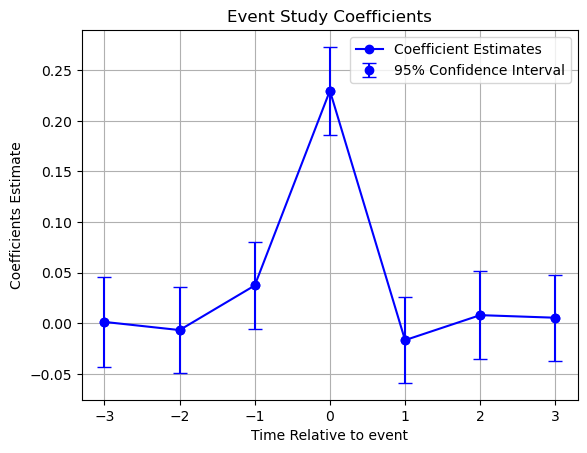

In [9]:
# TO-DO: PLOT THE COEFFICIENTS FROM PRE3 TO POST3. 
# THE X AXIS SHOULD BE INTEGERS RANGING FROM -3 TO +3 INCLUSIVE
# THE Y AXIS SHOULD TAKE THE COEFFICIENT VALUES FROM THE REGRESSION ABOVE 
# BONUS: CAN YOU ADD ERROR BARS? 

coefficients = model.params.index[-7:]
x_values = np.arange(-3, 4)
y_values = [model.params[coef] for coef in coefficients]

# Add error bars using standard errors from model.bse
y_errors = [1.96*model.bse[coef] for coef in coefficients]

# Plot the coefficient estimates as a connected line graph
plt.plot(x_values, y_values, label='Coefficient Estimates', marker='o', color='b')
# Add error bars to the plot
plt.errorbar(x_values, y_values, yerr=y_errors, fmt='o', color='b', capsize=5, label='95% Confidence Interval')
#...
plt.title('Event Study Coefficients')
plt.ylabel('Coefficients Estimate')
plt.xlabel('Time Relative to event')
plt.xticks(x_values)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Most of the other pre and post coefficients are clearly not statistically significant, with p-values ranging from 0.445 to 0.949. The pre1 coefficient is the exception, with a p-value of 0.088, which might be evidence of some anticipatory effects on the day before the CEO announcement.

In addition to looking at the raw numbers, we can plot the coefficients and their confidence intervals over time to get a better picture of the treatment effects. Here we can see that the effect spikes immediately and then falls.